# Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
from matplotlib.colors import LinearSegmentedColormap, Normalize
from pathlib import Path

import scienceplots
plt.style.use(['science', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    T_SOLIDUS, T_LIQUIDUS
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    boundaries_data_selection, boundaries_data_color, colors_plots_cordon
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer, show_number_of_data, show_acquisition_time, 
    show_acquisition_start, show_acquisition_end
)
from TherMIFASOL.core.models.EmissivityEmpiricalLaws import (
    wagner_inspired_emissivity
)
from TherMIFASOL.core.utils.visualization import (
    interpolate_color
)



working_path = "../../../data/experiences/BoardCardFilter/DEC1/pyrometer"

In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


data_path_pyrometer = os.path.join(
    PATH_DATA, "experiences/4 BoardCardFilter/DEC1/pyrometer/"
)
saving_path = os.path.join(BASE_DIR, "results/4 BoardFilter/FirstOrder")

# Full time data visualization

The pyrometer records three scalar values at a high frequency, approximately 8 kHz. These values include:
- monochromatic temperature from channel 1
- monochromatic temperature from channel 2
- bichromatic temperature from SENSORTHERM development

Analog inputs enable temporal synchronization with a signal from the additive manufacturing machine via G-code.

Our offline developments allow us to manipulate the two monochromatic temperatures to create our bichromatic camera and calculate our emissivity coefficient.

The pyrometer generates a file for each bead. This section aims to visualize our bichromatic temperature and emissivity coefficient throughout the wall manufacturing process.

## Full time data
This subsection presents the temporal data for the bichromatic temperature and emissivity coefficient of our development for relevant layer IDs.

In [3]:
list_beads:list = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
full_time_history = []
full_time_temperature = []
full_time_emissivity = []

start_acquisition = []
end_acquisition = []

for id_bead in list_beads:
    path_data_bead:str = os.path.join(data_path_pyrometer, f"WLAM_H322_14150_{id_bead}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)
    show_acquisition_time(dict_data_bead)
    #------------------------------------

    start_acquisition.append(dict_data_bead['debut acquisition'])
    end_acquisition.append(dict_data_bead['fin acquisition'])
    # print(f"Bead {id_bead}")
    # show_number_of_data(dict_data_bead)
    # show_acquisition_time(dict_data_bead)
    # show_acquisition_start(dict_data_bead)
    # show_acquisition_end(dict_data_bead)
    # print("\n\n")
    #------------------------------------
    
    bead_time = dict_data_bead['array absolute time']
    bead_temperature = dict_data_bead['array MAtemp2C']
    bead_emissivity = dict_data_bead['array MAemissivity']
    data_to_keep = bead_temperature > 552
    
    fake_time = np.copy(bead_time)
    fake_time-=fake_time[0]
    # np.save(file=f'time_layer_{id_bead}', arr=fake_time)
    # np.save(file=f'temperature_layer_{id_bead}', arr=bead_temperature)
    # np.save(file=f'emissivity_layer_{id_bead}', arr=bead_emissivity)

    full_time_history += list(bead_time[data_to_keep])
    full_time_temperature += list(bead_temperature[data_to_keep])
    full_time_emissivity += list(bead_emissivity[data_to_keep])

full_time_history=np.asarray(full_time_history)
full_time_history-=full_time_history[0]

full_time_temperature=np.asarray(full_time_temperature)
full_time_emissivity=np.asarray(full_time_emissivity)

Acquisition time : 4.558968 sec
Acquisition time : 4.558416 sec
Acquisition time : 4.558529 sec
Acquisition time : 4.568639 sec
Acquisition time : 4.569374 sec
Acquisition time : 4.569378 sec
Acquisition time : 4.262417 sec
Acquisition time : 4.5647839999999995 sec
Acquisition time : 4.5649560000000005 sec
Acquisition time : 4.278296 sec
Acquisition time : 4.565504 sec
Acquisition time : 4.261327 sec
Acquisition time : 4.589066 sec


In [4]:
from datetime import datetime
time_format = "%H:%M:%S,%f"

init_start_tim = datetime.strptime(start_acquisition[0], time_format)
init_fin_tim = datetime.strptime(end_acquisition[0], time_format)

for i in range(len(start_acquisition)-1):
    start_str = start_acquisition[i+1]
    end_str = end_acquisition[i+1]

    # Conversion des chaînes de caractères en objets datetime
    start_time = datetime.strptime(start_str, time_format)
    end_time = datetime.strptime(end_str, time_format)

    # Calcul de la différence
    difference_start = start_time - init_start_tim
    difference_end = end_time - init_fin_tim

    print(f"Différence pour la start : {difference_start}")
    print(f"Différence pour la start : {difference_end}")

    init_start_tim = start_time
    init_fin_tim = end_time

Différence pour la start : 0:00:35.382531
Différence pour la start : 0:00:35.381979
Différence pour la start : 0:00:31.384896
Différence pour la start : 0:00:31.385009
Différence pour la start : 0:00:29.373119
Différence pour la start : 0:00:29.383229
Différence pour la start : 0:00:29.286038
Différence pour la start : 0:00:29.286773
Différence pour la start : 0:00:29.912039
Différence pour la start : 0:00:29.912043
Différence pour la start : 0:00:29.615185
Différence pour la start : 0:00:29.308224
Différence pour la start : 0:00:30.114058
Différence pour la start : 0:00:30.416425
Différence pour la start : 0:00:32.008086
Différence pour la start : 0:00:32.008258
Différence pour la start : 0:00:32.192347
Différence pour la start : 0:00:31.905687
Différence pour la start : 0:00:29.322151
Différence pour la start : 0:00:29.609359
Différence pour la start : 0:00:29.896667
Différence pour la start : 0:00:29.592490
Différence pour la start : 0:00:29.072620
Différence pour la start : 0:00:29

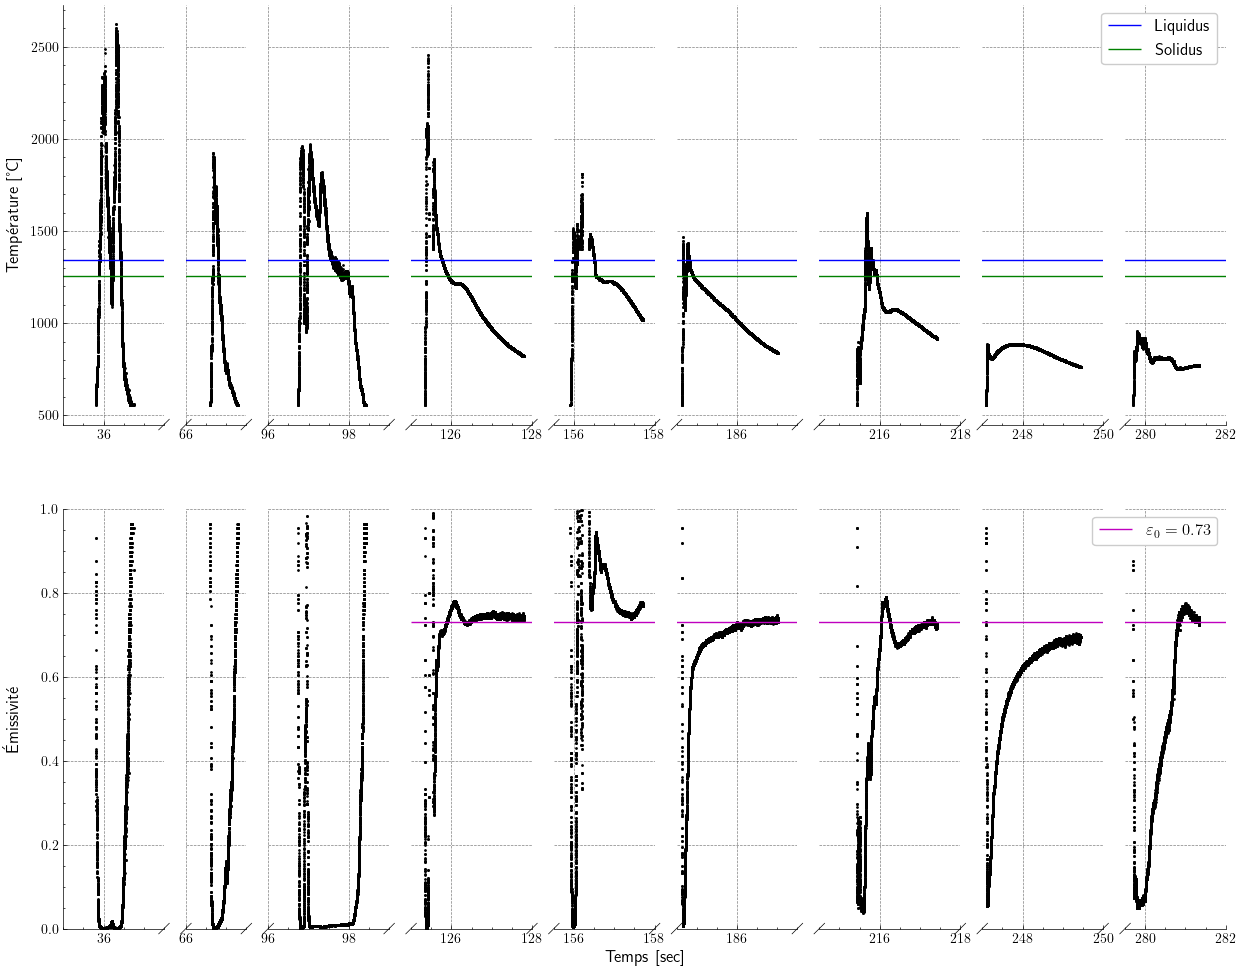

In [4]:
# plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'
# plt.rcParams['font.serif'] = 'Times New Roman'  # Specific font
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial']
})

fig = plt.figure(figsize=(15, 12))

# First sub-graph
bax1 = brokenaxes(
    xlims=((35, 37.5), (66, 67.5), (96, 99), (125, 128), (155.5, 158), (184.5, 187.5), (214.5, 218), (247, 250), (279.5, 282)),
    hspace=.1,
    subplot_spec=fig.add_gridspec(2, 1)[0],
    d=0.005
)
bax1.scatter(full_time_history, full_time_temperature, s=1, c='k')
bax1.hlines(
    y=T_LIQUIDUS-273.15, 
    xmin=full_time_history[0], 
    xmax=full_time_history[-1], 
    color="b", lw=1, label='Liquidus'
    )
bax1.hlines(
    y=T_SOLIDUS-273.15, 
    xmin=full_time_history[0], 
    xmax=full_time_history[-1], 
    color="g", lw=1, label='Solidus'
    )
# Second sub-graph
bax2 = brokenaxes(
    xlims=((35, 37.5), (66, 67.5), (96, 99), (125, 128), (155.5, 158), (184.5, 187.5), (214.5, 218), (247, 250), (279.5, 282)),
    hspace=.1,
    subplot_spec=fig.add_gridspec(2, 1)[1],
    d=0.005
)
bax2.scatter(full_time_history, full_time_emissivity, c='k', s=1)
bax2.hlines(
    y=0.73, 
    xmin=125, 
    xmax=full_time_history[-1], 
    color="m", lw=1, label=r'$\varepsilon_{0} = 0.73$'
    )


# Settings
bax1.set_ylabel('Température [°C]')
bax1.legend()
bax2.set_xlabel('Temps [sec]')
bax2.set_ylabel('Émissivité')
bax2.set_ylim(0, 1)
bax2.legend()

for ax in bax1.axs:
    ax.tick_params(axis='both', which='major', labelsize=10)
for ax in bax2.axs:
    ax.tick_params(axis='both', which='major', labelsize=10)


# Afficher le graphique
plt.show()


## Sub-selection from id 11 to id 15
The subsection focuses on relevant layer recordings because they represent the data when the melt pool is near the pyrometer's observation area.

In [6]:
list_relevant_beads:list = [14, 15, 16, 17, 18, 19]
DATA:dict = {id_relevant_beads:{} for id_relevant_beads in list_relevant_beads}

for id_relevant_beads in list_relevant_beads:
    # low_boundary, _ = boundaries_data_selection[id_relevant_beads]
    
    path_data_bead:str = os.path.join(data_path_pyrometer, f"WLAM_H322_14150_{id_relevant_beads}.csv")
    dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)
   
    # mask = dict_data_bead['array time'] > low_boundary
    mask = dict_data_bead['array time'] > -1

    # DATA[id_relevant_beads]['array time'] = dict_data_bead['array time'][mask] - low_boundary
    DATA[id_relevant_beads]['array time'] = dict_data_bead['array time'][mask]
    DATA[id_relevant_beads]['array MAtemp2C'] = dict_data_bead['array MAtemp2C'][mask]
    DATA[id_relevant_beads]['array MAemissivity'] = dict_data_bead['array MAemissivity'][mask]

## Temporal pyrometric readings

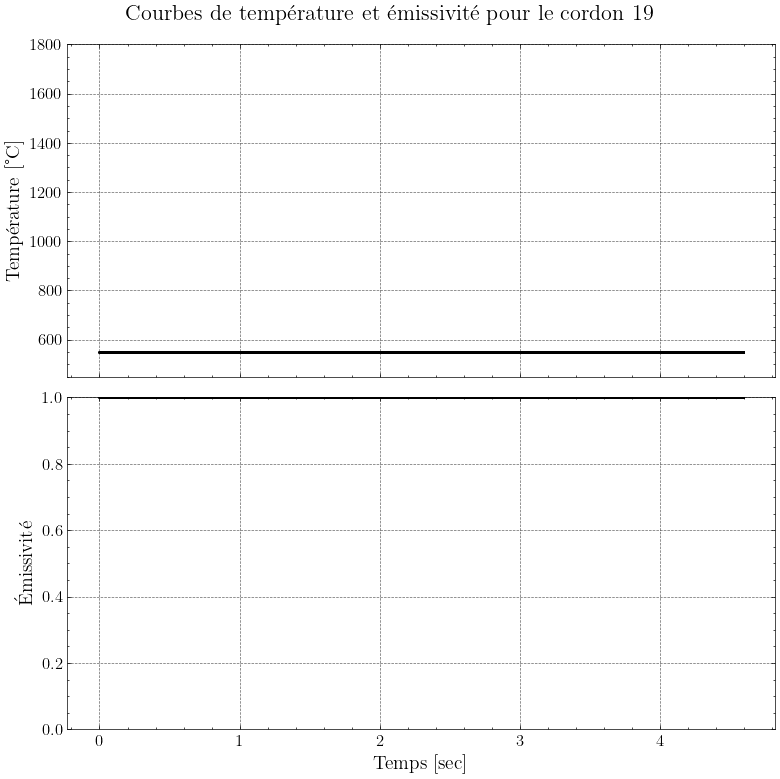

In [17]:
# Sélectionne la clé du dictionnaire (par exemple, 11)
key = 19

# Récupère les données
TIME = DATA[key]['array time']
TEMP2C = DATA[key]['array MAtemp2C']
EPSILON = DATA[key]['array MAemissivity']

# Crée une figure avec 2 sous-graphiques (température et émissivité)
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Tracé de la température (ligne 1)
axs[0].scatter(TIME, TEMP2C, s=1, c='k')
axs[0].set_ylabel('Température [°C]', fontsize=14)
axs[0].set_ylim(ymin=450, ymax=1800)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Tracé de l'émissivité (ligne 2)
axs[1].scatter(TIME, EPSILON, c='k', s=1)
axs[1].set_ylabel('Émissivité', fontsize=14)
axs[1].set_ylim(0, 1)
axs[1].set_xlabel('Temps [sec]', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.6)

# Configuration des ticks
for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=12)

# Ajoute un titre
fig.suptitle(f'Courbes de température et émissivité pour le cordon {key}', fontsize=16)

# Ajuste l'espacement
fig.tight_layout()

# Affichage
plt.show()

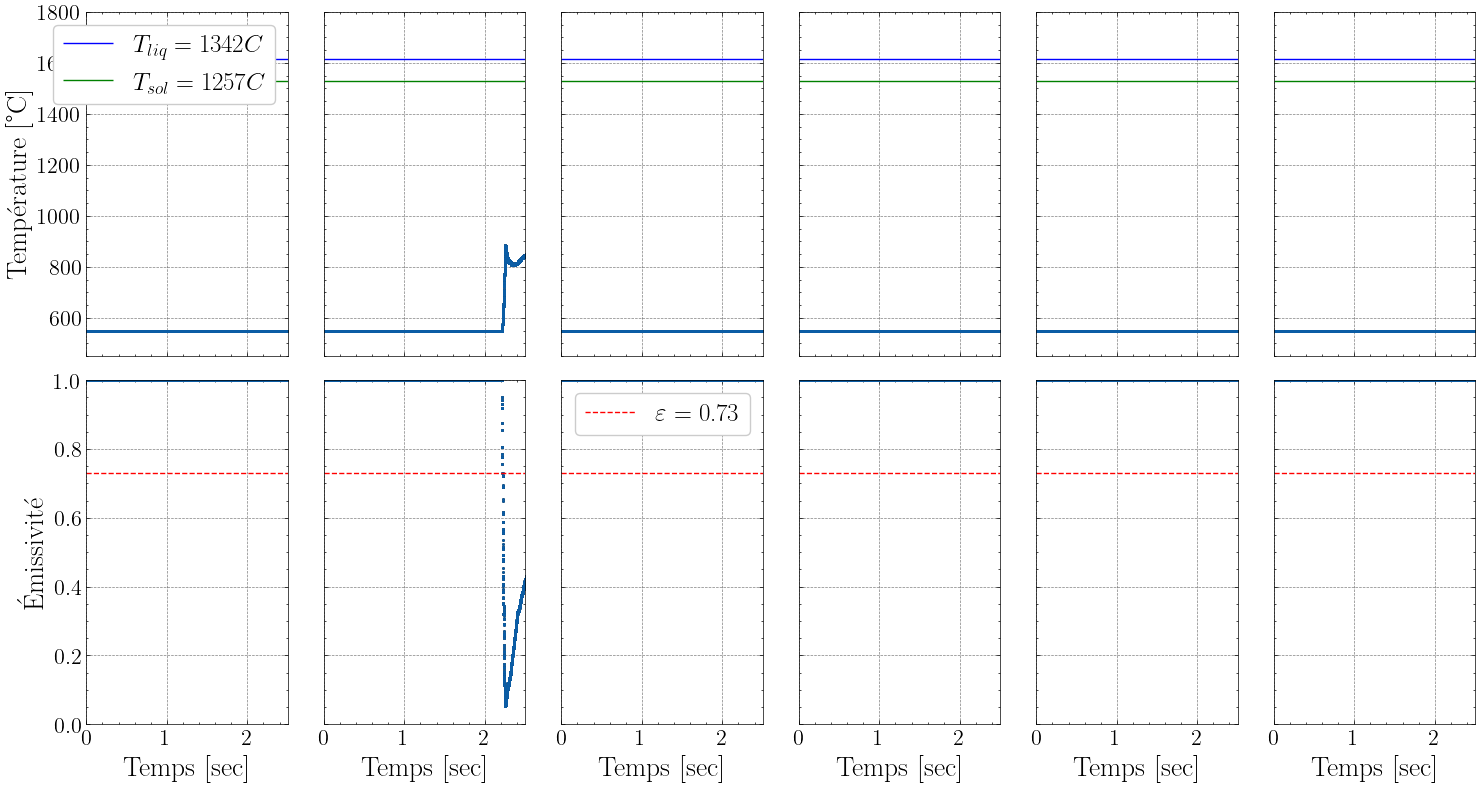

In [ ]:
cordon_selection = [11, 13, 15]

fig, axs = plt.subplots(2, len(cordon_selection), figsize=(15, 8), sharex='col', sharey='row')  # 2 lignes, 3 colonnes, partage x/y
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = DATA[cordon]['array time']
    TEMP2C = DATA[cordon]['array MAtemp2C']
    EPSILON = DATA[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    # Tracer la température (ligne 1)
    axs[0, idx].scatter(TIME, TEMP2C, s=1, c='k')
    axs[0, idx].scatter(TIME[MASK_COLOR], TEMP2C[MASK_COLOR], s=1, color=colors_plots_cordon[cordon])
    axs[0, idx].hlines(y=T_LIQUIDUS, xmin=TIME[0], xmax=TIME[-1], colors='b', label=r'$T_{liq} = 1342 °C$')
    axs[0, idx].hlines(y=T_SOLIDUS, xmin=TIME[0], xmax=TIME[-1], colors='g', label=r'$T_{sol} = 1257 °C$')

    axs[1, idx].hlines(y=0.73, xmin=TIME[0], xmax=TIME[-1], color='r', ls='--', label=r'$\varepsilon$ = 0.73')
    axs[0, idx].set_ylim(ymin=450, ymax=1800)
    
    if idx == 0:
        axs[0, idx].legend(fontsize=18)
    if idx == 2:
        axs[1, idx].legend(fontsize=18)
    
    if idx == 0:
        axs[0, idx].set_ylabel('Température [°C]', fontsize=20)
        axs[1, idx].set_ylabel('Émissivité', fontsize=20)

    # Tracer l'émissivité (ligne 2)
    axs[1, idx].scatter(TIME, EPSILON, c='k', s=1)
    axs[1, idx].scatter(TIME[MASK_COLOR], EPSILON[MASK_COLOR], color=colors_plots_cordon[cordon], s=1)
    axs[1, idx].set_ylim(0, 1)      
    
    axs[1, idx].set_xlabel('Temps [sec]', fontsize=20)

for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_xlim(0, 2.5)

fig.tight_layout()
plt.show()

## Temperature - Emissivity plan 

### Plot of selected data

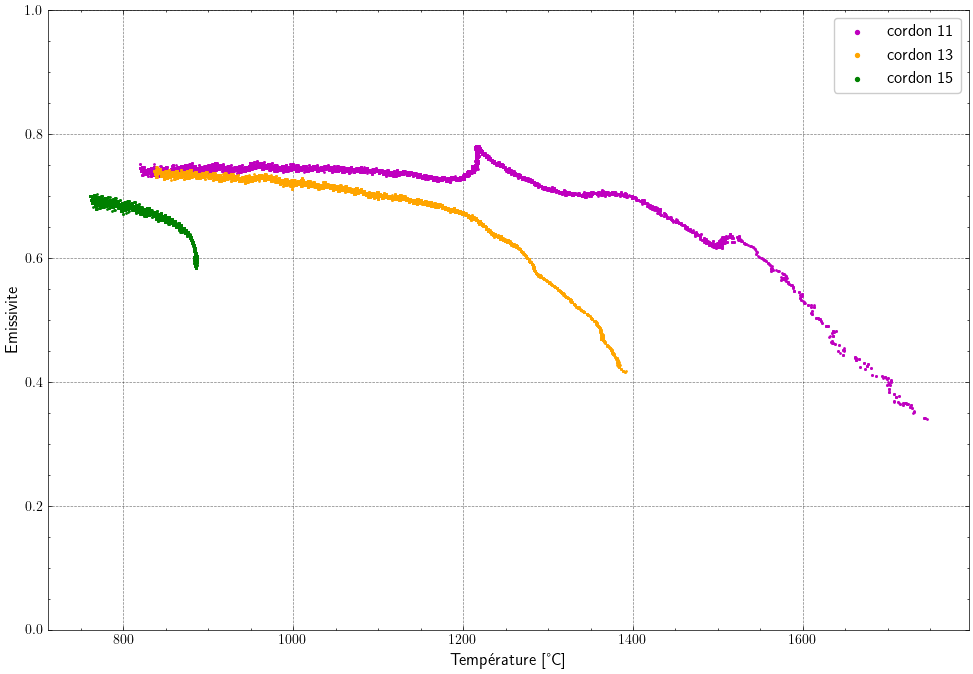

In [7]:
fig, ax1 = plt.subplots(1, 1, figsize=(10,7))
for idx, cordon in enumerate(cordon_selection):
    low_boundary, high_boundary = boundaries_data_selection[cordon]
    TIME = DATA[cordon]['array time']
    TEMP2C = DATA[cordon]['array MAtemp2C']
    EPSILON = DATA[cordon]['array MAemissivity']
    MASK_COLOR = TIME > boundaries_data_color[cordon]

    ax1.scatter([np.mean(TEMP2C)], [-5], c=colors_plots_cordon[cordon], s=8, label=f'cordon {cordon}')
    ax1.scatter(TEMP2C[MASK_COLOR], EPSILON[MASK_COLOR], s=1, c=colors_plots_cordon[cordon])

ax1.set_ylabel('Emissivite', fontsize=12)
ax1.set_ylim(0,1)
ax1.set_xlabel('Température [°C]', fontsize=12)
ax1.legend(fontsize=12)

ax1.tick_params(axis='both', which='major', labelsize=10)
fig.tight_layout()
plt.show()

### Selected data & analytical fitted laws

#### Color map creation

In [8]:
iterations = [0, 0.8, 1.6]  # Profondeur en mm, avec 1.6 mm ajouté ici
iterations2 = [1.6, 2.6, 3.2]  # Profondeur en mm

# Inverser l'ordre pour que 0 soit en haut de la colorbar
iterations = sorted(iterations, reverse=True)
iterations2 = sorted(iterations2, reverse=True)

# Création d'un dégradé fluide de magenta à orange et d'orange à noir
scalars_magenta_to_orange = np.linspace(0, 1, 90)  # De magenta à orange
colors_magenta_to_orange = [interpolate_color((0.75, 0, 0.75), (1, .647, 0), scalar) for scalar in scalars_magenta_to_orange]

# Création d'un dégradé fluide d'orange à noir
scalars_orange_to_black = np.linspace(0, 1, 90)  # De orange à noir
# colors_orange_to_black = interpolate_to_black((1, .647, 0), scalars_orange_to_black)
colors_orange_to_green = [interpolate_color((1, .647, 0), (0, 0.5, 0), scalar) for scalar in scalars_orange_to_black]

# Combinaison des deux pour un dégradé fluide de magenta -> orange -> noir
colors_combined = colors_magenta_to_orange + colors_orange_to_green

# Création de la colormap avec la combinaison des couleurs
cm_smooth = LinearSegmentedColormap.from_list("magenta_to_black", colors_combined, N=200)
norm = Normalize(vmin=min(iterations), vmax=max(iterations2))  # Ajustement pour inclure la profondeur totale

#### Subdata collection

In [9]:
MASK15 = DATA[15]['array time'] > boundaries_data_color[15]
temperature15 = DATA[15]['array MAtemp2C'][MASK15]
epsilon15 = DATA[15]['array MAemissivity'][MASK15]

MASK13 = DATA[13]['array time'] > boundaries_data_color[13]
temperature13 = DATA[13]['array MAtemp2C'][MASK13]
epsilon13 = DATA[13]['array MAemissivity'][MASK13]

MASK11 = DATA[11]['array time'] > boundaries_data_color[11]
temperature11 = DATA[11]['array MAtemp2C'][MASK11]
epsilon11 = DATA[11]['array MAemissivity'][MASK11]

#### Plot data

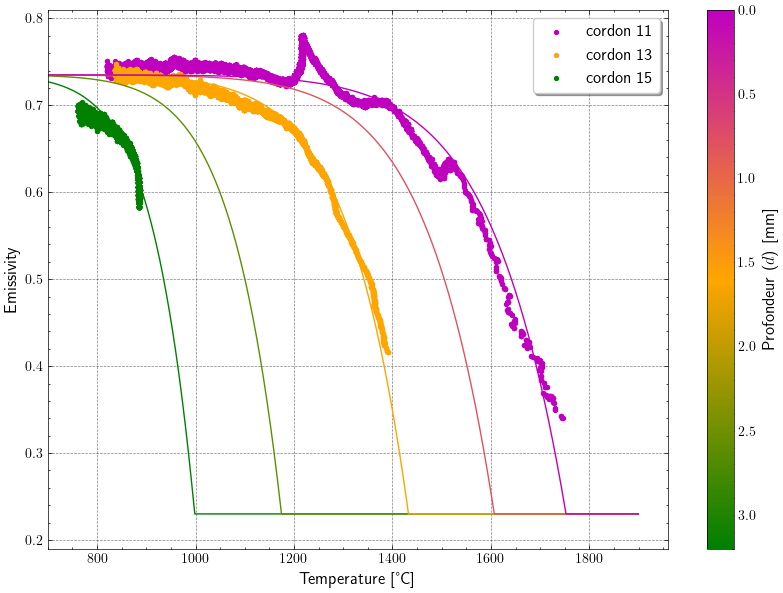

In [12]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))
temp_fake = np.arange(700, 1900, 0.5)

# Ajout des scatter plots pour les cordons 11 et 13
ax1.scatter(temperature11, epsilon11, label='layer 11', color='m', s=8)
ax1.scatter(temperature13, epsilon13, label='layer 13', color='orange', s=8)
ax1.scatter(temperature15, epsilon15, label='layer 15', color='g', s=8)

# Itérations pour les lignes avec la nouvelle loi
for cpt, v in enumerate(iterations2 + iterations[1:]):
    new_eps = wagner_inspired_emissivity(
        temperature=temp_fake, 
        depth=v, 
        unit='mm', 
        block=False, 
        evolution='quadratic', 
        eps_min=0.23
        )
    ax1.plot(temp_fake, new_eps, c=cm_smooth(norm(v)))

# Ajustement de la colorbar avec inversion des valeurs (profondeur de 0 en haut)
sm = plt.cm.ScalarMappable(cmap=cm_smooth, norm=norm)
sm.set_array([])  # Nécessaire pour utiliser la colorbar
cbar = plt.colorbar(sm, ax=ax1)
cbar.set_label(r'Profondeur ($d$) [mm]', fontsize=12)
cbar.ax.tick_params(axis='y', which='major', labelsize=10)
cbar.ax.invert_yaxis()  # Inverse l'axe de la colorbar pour montrer 0 en haut

# Ajustements finaux
ax1.set_ylim(0.19, 0.81)
ax1.set_xlim(xmin=700)
ax1.tick_params(axis='both', which='major', labelsize=10)
plt.legend(['cordon 11', 'cordon 13', 'cordon 15'], loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.xlabel('Temperature [°C]', fontsize=12)
plt.ylabel("Emissivity", fontsize=12)
plt.show()